<a href="https://colab.research.google.com/github/karimjunaidi/ML-fundamentals-2026/blob/main/assignment_1_karim_junaidi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading the dataset

In [5]:
import pandas as pd
df = pd.read_csv('bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# TASK 1: IDENTIFYING TARGET VARIABLE

In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

## Target Variable

  The target variable that seems most appropriate here is 'y', which represents the clients that did/did not subscribe to a term deposit following a campaign conducted by the Portuguese banking institution. This seems to be the appropriate target variable since it appears to align with the outcome the bank cares about: trying to identify which clients are likely to subscribe in advance in order to allocate resources more efficiently. As discussed in Lecture 1, a well-defined ML goal requires clearly specified inputs and outputs. In this case, the inputs are client and campaign attributes available at the time of contact, and the output is the subscription decision.

## Variables that could falsely appear as Target Variables

**1. 'poutcome' : outcome of previous marketing campaign**

The name of this variable contains the word outcome, which could lead to someone mistakingly assuming it is indeed the target variable, when in fact it is not. However, this variable records the result of a *previous* campaign, not the one we are concerned with right now. It is historical data that should be treated as a feature, not our target variable.

**2. 'duration' : last contact duration in seconds**

This variable could be mistakingly treated as a target variable because it behaves like an outcome — it is known after the call has ended, making it unavailable during the time of prediction, which may lead to an analyst thinking it could serve as a target variable in this case. As previously mentioned, a well-specified ML problem requires that all inputs be available at the time of prediction, therefore invalidating this variable as a useful feature, and since the business objective is to predict subscriptions, it cannot serve as a target variable either.

*AI Disclosure: Claude (Anthropic, https://claude.ai) was used as a thinking aid
for this section. The prompts used include: asking Claude to explain what makes a
valid prediction target, discussing why duration and poutcome could be falsely
identified as targets, and requesting feedback on my written explanation. All text
was written and reworded in my own words.*

# TASK 2: DATA LOADING AND EXPLORATION

### Inspecting the structure of the dataset

In [7]:
# All code blocks in this task were generated by Claude (Anthropic, https://claude.ai).
# The prompts used include: asking Claude how to properly inspect the structure of a dataset, exploring missing values
# and plotting and analysing categorical and numerical variables, and distinguishing one variable that could require special treatment
print(f"Number of observations: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")  # excluding target
print(f"Total columns: {df.shape[1]}")

Number of observations: 41188
Number of features: 20
Total columns: 21


In [8]:
print(df.shape)

(41188, 21)


### Checking the number of categorical and numerical variables

In [9]:
print(df.dtypes)

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


**10 numerical variables:** age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

**11 categorical variables:** job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome, y

In [10]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


A few things stand out here:
The mean of 'duration' is 258 seconds with a maximum of 4918 suggesting there's an extreme outlier there. The minimum is 0, which definitely stands out as a call cannot last 0 seconds, maybe implying a failed connection. The 'campaign' variable has a mean of 2.6 but a max of 56, confirming the right skew seen earlier. 75% of clients were contacted less than 3 times yet someone was contacted 56 times. The 'previous' variable has a mean of 0.17 with a 75th percentile of 0, implying the majority of clients were never previously contacted, which is consistent with our pdays finding. The 'pdays' variable has a mean of 962 yet the 25th, 50th and 75th percentiles are all 999, implying at least 75% of the values are the sentinel value. These anomalies show the importance careful data inspection before modeling, as discussed in Lecture 2.

In [11]:
df.describe(include = 'object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


The categorical summary reveals some interesting observations. The 'poutcome' variable is dominated by nonexistent (35,563/41,188), confirming the majority of clients had no previous campaign contact. The 'default' variable has only 3 unique values, implying there's an 'unknown' category besides yes and no. In addition, 'month' only has 10 unique values, suggesting the bank did not actually conduct campaigns in all months of the year.

### Analyzing target variable

In [12]:
df['y'].value_counts()

,count
y,
no,36548
yes,4640


In [13]:
df['y'].value_counts(normalize=True) * 100

,proportion
y,
no,88.734583
yes,11.265417


The dataset exhibits a clear class imbalance, with 88.7% not subscribing and 11.3% subscribing. This is a concern since models trained on imbalanced data may become biased towards the majority class. This will be addressed in a later task.

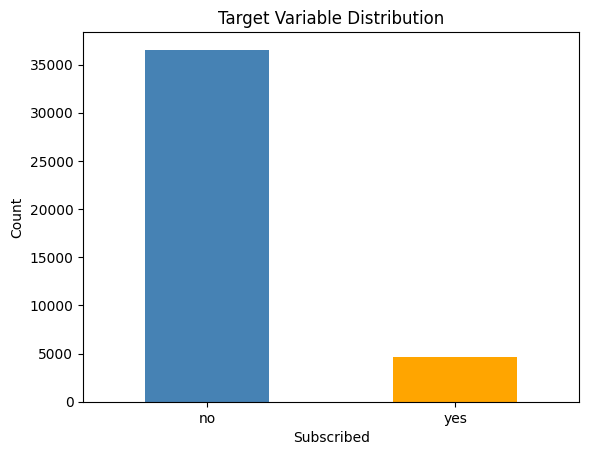

In [14]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Target Variable Distribution')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Detecting implicit and explicit missing values

In [15]:
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [16]:
for col in df.select_dtypes(include='object').columns:
    if 'unknown' in df[col].values:
        print(f"{col}: {(df[col] == 'unknown').sum()} unknowns")

job: 330 unknowns
marital: 80 unknowns
education: 1731 unknowns
default: 8597 unknowns
housing: 990 unknowns
loan: 990 unknowns


In [17]:
print(f"pdays value of 999: {(df['pdays'] == 999).sum()}")
print(f"pdays other values: {(df['pdays'] != 999).sum()}")

pdays value of 999: 39673
pdays other values: 1515


No explicit missing values detected. However, several categorical variables contain implicit missing values in the form of 'unknown' categories: job(330), marital(80), education(1,731), defualt(8,597), housing(990), and loan(990). In addition, pdays has 39,673 sentinel values of 999, indicating that the vast majority of of clients were never previously contacted. We will address these missing values in a later task.

### Visualizing distributions of 2 categorical and 2 numerical variables

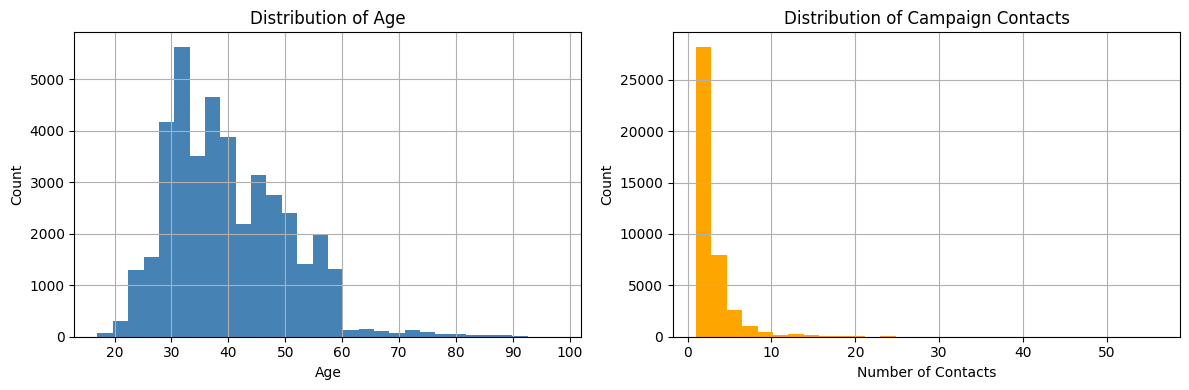

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['age'].hist(bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

df['campaign'].hist(bins=30, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Campaign Contacts')
axes[1].set_xlabel('Number of Contacts')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

The distribution of age is right-skewed, with the majority falling between 30 and 60 years old. There's a long tail of older clients (70+), but they represent a small portion of the dataset, implying the bank's target audience is seem to be working-age adults. The distribution of campaign contacts is extremely skewed to the right, with most clients being contacted between 1-3 times. However, there does appear to be an extreme outlier of 56. This may require treatment before modeling.

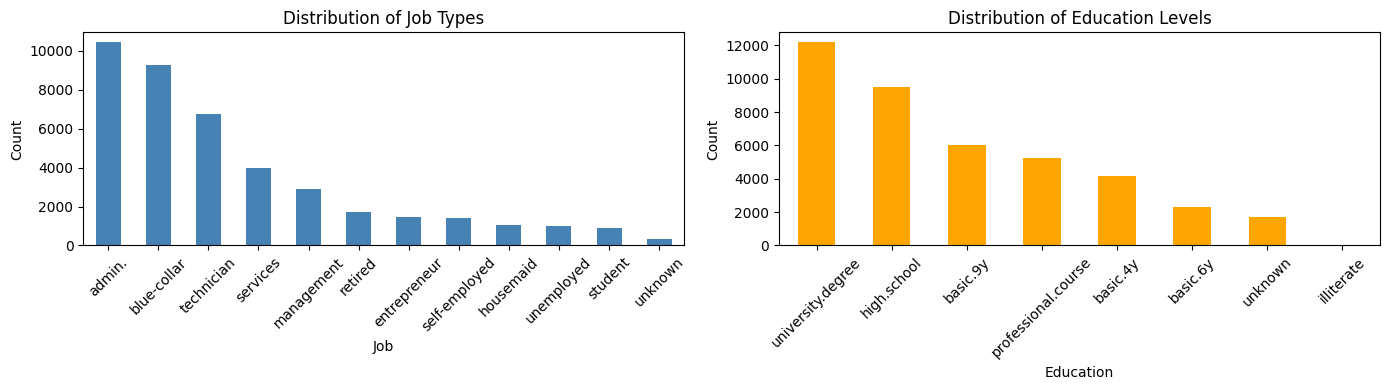

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['job'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Job Types')
axes[0].set_xlabel('Job')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['education'].value_counts().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Distribution of Education Levels')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The job distribution shows that 'admin' and 'blue-collar' are the most represented categories, together accoutning for a large portion of the dataset. The 'unknown' category is clearly the smallest, which is consistent with our previous observation of 330 unknowns.

### Identifying one variable that could need special consideration

I think the 'campaign' variable requires special consideration before modeling due to it's extreme right-skew. Most clients were contacted between 1 or 3 times (75% definitely less than 3 according to previous finding) with a maximum value of 56. This extreme outlier could negatively impact the performance of our predictive model.

*AI Disclosure: Claude (Anthropic, https://claude.ai) was used as a thinking aid
for this entire task section. The prompts used include: asking Claude to suggest which variables
to visualize, requesting paragraphs to paraphrase for each observation, and
discussing the implications of class imbalance and missing values. All text was
reworded and written in my own words.*

# TASK 3: TASK ORDERING

### Chosen Order:
1. Identifying the Prediction Target

this comes first since all decisions made essentially depend on knowing what we are trying to predict. Without a clear target variable, we cannot make effective informed decisions about which features are important, or how to evaluate the model. **Allowed:** inspecting column definitions and understanding original business problem. **Must not use:** no statistics or transformations should be used at this stage. **If the order is changed:** risk making data preparation decisions without an actual clear objective, potentially keeping leaky variables or misidentifying which column to predict.

2. Data Loading and Exploration

this comes second because before we make any modeling decisions, we need to fully understand the structure of our data. **Allowed:** the entire dataset can be used here. **Must not use:** no statistics should be learned or transformed at this stage. **If order is changed:** performing data exploration after splitting could cause us to miss important patterns in the data, performing any transformations at this stage before splitting would introduce data leakage, as those transformations would be informed by the entire dataset including what should be unseen test data.

3. Task Ordering

**Allowed:** observations from the exploration stage can help us determine a good task ordering. **Must not use:** no data statistics or transformations should be used at this stage. **If order is changed:** if task ordering was concluded before data exploration, we could potentially make incorrect pipeline decisions without the awareness of important data characteristics like class imbalance, sentinel values or missing values discovered during exploration.

4. Managing Missing Values (cleaning only)

**Allowed:** the entire dataset can be used for cleaning decisions that do not learn anything from the data, like replacing 'unknown' strings with NaN. **Must not use:** no imputation stats such as mean or mode should be computed at this stage, as they must be learned for the training set. **If order is changed:** if we imputed the missing values before splitting, the imputation statistics would be calculated using the entire dataset including the test set, introducing data leakage.

5. Data Splitting

**Allowed:** the cleaned dataset(after missing value cleaning) can be used to perform the split. Stratification on the target variable is allowed and necessary to because of the class imbalance found during the data exploration stage. **Must not use:** no transformation statistics like means or encodings or scaling parameters should have been learned before this point. **If order is changed:** if splitting were performed after any transformation that learns the statistics from the data, then the stats would be learned on the entire dataset including the test set, introducing data leakage.

6. Managing Missing Values (imputation)

**Allowed:** imputation statistics like the mean and median can now be computed, but only on the training set. These stats are then applied to the validation and test sets. **Must not use:** imputation stats from validation or test sets. **If order is changed:** if imputation were performed before splitting, the imputation would be informed by the entire dataset including the test set, introducing data leakage and causing the model to see information it should not have seen during training.

7. Encoding Categorical Variables

**Allowed:** encoding strategies can be fitted using only the training set, then later applied to validation and test sets. **Must not use:** encoding parameters must not be learned from the validation or test sets. **If order is changed:** if performed before splitting, the encoder would be fitted on the entire dataset including the test set, introducing data leakage as the model would then indirectly learn information about the distribution of categories in the test set during training.

8. Feature Scaling

**Allowed:** scaling parameters such as mean and standard deviation can be computed using the training set only, later applied to the validation and test sets. **Must not use:** scaling parameters must not be learned from the validation and test sets. **If order is changed:** if scaling were performed before splitting, the scaling parameters would be computed using the entire dataset, including the validation and test sets, introducing data leakage.

9. Feature Selection

**Allowed:** Feature selection decisions such as variance thresholds and correlation analysis can be performed using only the training set, then later applied to validation and test. **Must not use:** feature selection must not be informed by the validation or test sets. **If order is changed:** if performed before splitting, then like the previous steps, the selection criteria would be informed by the entire dataset including validation and test sets, introducing data leakage.

10. Addressing Class Imbalance

**Allowed:** resampling techniques (random over/under sampling) can be applied to the training set after splitting, encoding, and scaling have been done. **Must not use:** resampling must not be done to the validation or test sets, because it has to preserve the original class distribution. **If order is changed:** resampling could be distributed across the training, validation and test sets, introducing data leakage and producing metrics that would not be a good reflection of real-world performance.

11. Training a Logistic Regression Model

**Allowed:** the fully preprocessed training set can be used to train the model and the validation set can be used to generate predictions and evaluate performance. **Must not use:** the test set. **If order is changed:** if the model was trained before preprocessing, it would be trained on raw, unscaled, unencoded data which would yield unreliable results.


This chosen order follows a strict pipeline discipline that is designed to prevent data leakage at every single stage. We start by identifying the target variable and exploring the data we have, as they do not require transformations and can inform us on all subsequent decisions. Afterwards, basic missing value cleaning is performed before splitting our data since it involves no statistical learning. We then split our data into training, validation and test sets before any transformations that learn from the data are applied. All steps that follow — imputation, encoding, scaling, feature selection etc. — are fitted exclusively on the training set and later applied to the validation and test sets, making sure that no information from unseen data has any effect on the training process. Finally, the model is trained on the fully preprocessed training set and evaluated on the validation set. This order makes sure that the model evaluation will lead to true generalization performance on unseen data.


A common example of incorrect ordering would be performing feature scaling before actually splitting the dataset. If we were to compute the mean and standard deviation of numerical features using the entire dataset and then split, the scaling parameters would have been scaled using information from the data that the model wasn't supposed to see, introducing data leakage. The consequence is that the model would be unreliable, as the model would have indirectly learned from the test set during training. When eventually deployed in the real world, the model would probably underperform since it would encounter truly unseen data that was not used to compute the scaling parameters.




*AI Disclosure: Claude (Anthropic, https://claude.ai) was used as a thinking aid
for this section. The prompts used include: discussing the correct pipeline order,
exploring data leakage implications at each stage, and seeking help understanding
what information is allowed and must not be used at each step. All text was
reworded and written in my own words.*


# TASK 4: MANAGING MISSING VALUES

### Identifying explicit and implicit missing values, as well as sentinel values

In [20]:
# Check for explicit missing values
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [21]:
# This code block was generated by Claude (Anthropic, https://claude.ai).
# The prompts used include: asking Claude how to detect implicit missing values such as 'unknown' categories in categorical variables.
for col in df.select_dtypes(include='object').columns:
    if 'unknown' in df[col].values:
        print(f"{col}: {(df[col] == 'unknown').sum()} unknowns")

job: 330 unknowns
marital: 80 unknowns
education: 1731 unknowns
default: 8597 unknowns
housing: 990 unknowns
loan: 990 unknowns


In [22]:
# This code block was generated by Claude (Anthropic, https://claude.ai).
# The prompts used include: asking Claude how to check for sentinel values in a pandas column.
print(f"pdays value of 999: {(df['pdays'] == 999).sum()}")
print(f"pdays other values: {(df['pdays'] != 999).sum()}")

pdays value of 999: 39673
pdays other values: 1515


No explicit missing values detected. However, several categorical variables contain implicit missing values in the form of 'unknown' categories: job(330), marital(80), education(1,731), defualt(8,597), housing(990), and loan(990). In addition, pdays has 39,673 sentinel values of 999, indicating that the vast majority of of clients were never previously contacted.

### Quantifying the extent of missingness for each affected variable

In [23]:
# This code block was generated by Claude (Anthropic, https://claude.ai).
# The prompts used include: asking Claude how to replace 'unknown' string values with NaN in pandas.
import numpy as np
df.replace('unknown', np.nan, inplace=True)

In [24]:
# This code block was generated by Claude (Anthropic, https://claude.ai).
# The prompts used include: asking Claude how to calculate the percentage of missing values for each variable in pandas.
missing_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']
for col in missing_cols:
    count = df[col].isnull().sum()
    pct = (count / len(df)) * 100
    print(f"{col}: {count} missing ({pct:.2f}%)")

print(f"pdays (sentinel 999): 39673 ({39673/len(df)*100:.2f}%)")

job: 330 missing (0.80%)
marital: 80 missing (0.19%)
education: 1731 missing (4.20%)
default: 8597 missing (20.87%)
housing: 990 missing (2.40%)
loan: 990 missing (2.40%)
pdays (sentinel 999): 39673 (96.32%)


### Proposing and justifying a strategy

As mentioned earlier, no explicit missing values were detecetd in the dataset. However, several categorical variables contain implicit missing values in the form of NaN values (previously 'unknown' strings), 'job' (0.80%), 'marital' (0.19%), 'education' (4.20%), 'default' (20.87%), 'housing' (2.40%) and 'loan' (2.40%). For these variables, the 'unknown' category will be retained as a separate category rather than imputed. This decision is justified by two reasons: Firstly, the missingness itself may be useful to us and carry some predictive information (a client whose default status is unknown may have a different behavior in comparison to someone whose default status is known). Secondly, as discussed in Lecture 2, imputation can artificially alter the original data's distribution, which we should preserve as much as possible. As for 'pdays', which contains about 96.32% sentinel values of 999, a binary indicator variable 'was_contacted_before' will be created, if the client was previously contacted then that client will take a value of 1, 0 otherwise. This preserves the meaningful information in the variable without the distortion of the numerical scale. Once splitting is complete, we will implement these decisions to ensure no information from the validation or test sets will have an influence on the training process.


The only operation in this task that must be fitted on the training set only is the newly created binary indicator for 'pdays'. Although retaining 'unknown' as a separate category requires no statistical learning and can actually be applied to the entire dataset safely, any transformation that derives parameters from the data must be fitted on the training set only and then apllied to the validation and test sets. Fitting on the entire dataset could introduce data leakage.



*AI Disclosure: Claude (Anthropic, https://claude.ai) was used as a thinking aid
for this section. The prompts used include: discussing strategies for handling
missing values, exploring the distinction between data cleaning and modeling
decisions, and seeking help understanding how Lecture 2 and Lecture 5 inform
our imputation strategy. All text was reworded and written in my own words.*



# TASK 5: DATA SPLITTING

### Initial split

In [25]:
# This code block was generated by Claude (Anthropic, https://claude.ai).
# The prompts used include: asking Claude how to perform stratified train/validation/test splitting using sklearn.
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['y'])
y = df['y']

# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: split temporary into 50/50 → 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Training set: (28831, 20)
Validation set: (6178, 20)
Test set: (6179, 20)


### Checking if stratification worked

In [26]:
print("Training set distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation set distribution:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTest set distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set distribution:
y
no     88.734348
yes    11.265652
Name: proportion, dtype: float64

Validation set distribution:
y
no     88.734218
yes    11.265782
Name: proportion, dtype: float64

Test set distribution:
y
no     88.736041
yes    11.263959
Name: proportion, dtype: float64


The dataset was split into a training(70%), validation(15%), and test(15%) sets. As discussed in Lecture 2, the training should be the largest portion of the data, with the validation and test sets being of similar size. With 41,188 observations, a 70% training set provides about 28,831 observations which I deem sufficient for the model to learn effectively, while the validation and test sets of about 6,178 observations each are large enough for reliable evaluation.


Stratified splitting was applied with respect to target variable 'y' due to the significant class imbalance that we identified during exploration. Without the stratification, the random split could produce different sets with different class balances, leading to unreliable model evaluation.

We must perform this split before performing any transformation that learns from our data. Performing this split later would mean any transformations would be fitted on the entire dataset including the test set, introducing data leakage producing inflated metrics.


*AI Disclosure: Claude (Anthropic, https://claude.ai) was used as a thinking aid
for this section. The prompts used include: discussing appropriate split proportions
for this dataset, understanding why stratification is necessary given class imbalance,
and exploring what data leakage would arise if splitting were performed later. All
text was reworded and written in my own words.*